In [24]:
import matplotlib.pyplot as plt
import polars as pl

from nwec.constants import CLEAN_UTILITY_DATA, Utility

In [25]:
arrearage_counts = pl.read_ipc(CLEAN_UTILITY_DATA / "arrearage_counts.arrow")

In [26]:
arrearage_counts

Utility,Zip Code,Month,Arrearage Count
str,str,date,i64
"""CNG""","""98370""",2025-06-01,151
"""PSE""","""98270""",2025-01-01,2303
"""PSE""","""98329""",2025-06-01,3
"""PAC""","""98938""",2025-06-01,181
"""NWN""","""98675""",2025-06-01,0
…,…,…,…
"""CNG""","""98383""",2025-05-01,258
"""PAC""","""98944""",2025-03-01,2094
"""CNG""","""98674""",2025-06-01,113


In [27]:
# Aggregate arrearage counts by utility and month
df_grouped = arrearage_counts.group_by(["Utility", "Month"]).agg(pl.col("Arrearage Count").sum()).sort("Month")

# Pivot to get utilities as columns
df_pivot = df_grouped.pivot(values="Arrearage Count", index="Month", on="Utility").sort("Month")

df_pivot

Month,PAC,CNG,PSE,NWN,Avista
date,i64,i64,i64,i64,i64
2025-01-01,25159,18352,233315,9400,25299
2025-02-01,26707,16691,232214,10842,24577
2025-03-01,28704,19880,239463,13309,27875
2025-04-01,31078,18663,191294,14347,27603
2025-05-01,32322,20251,197436,14601,30359
2025-06-01,28894,19802,180391,13059,29728


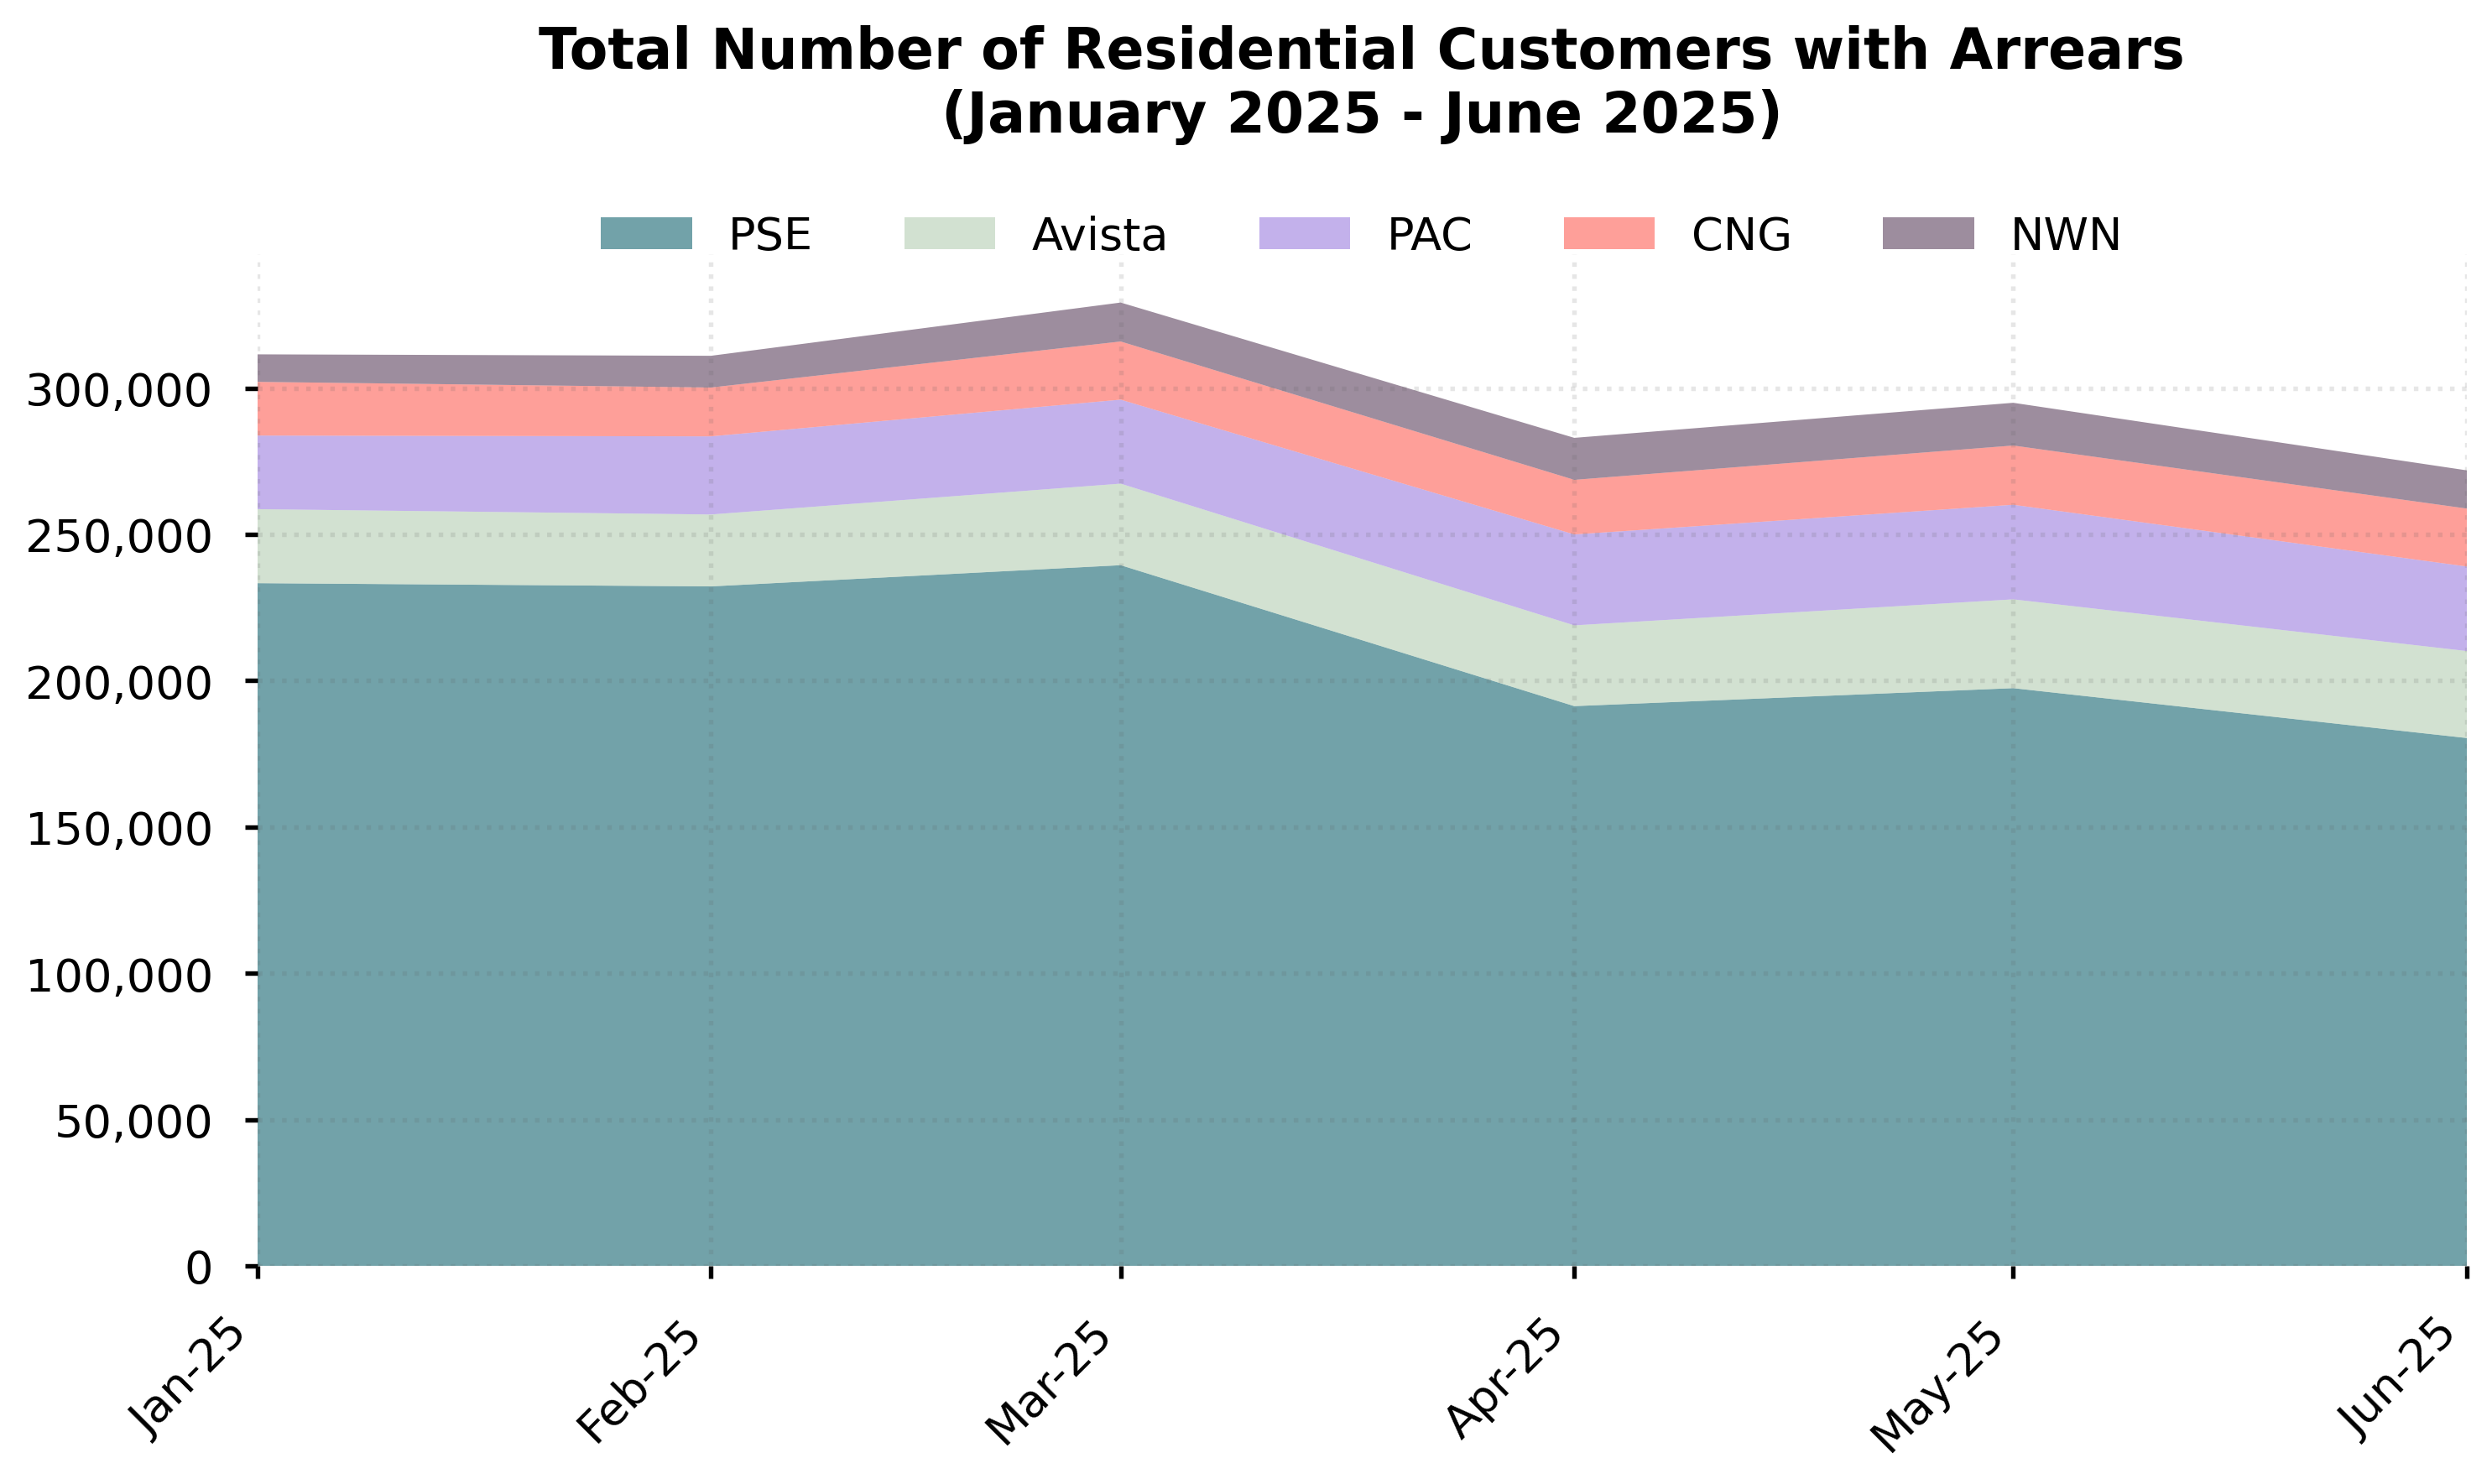

In [28]:
# Create stacked area chart for arrearage counts by utility
from matplotlib.dates import DateFormatter

with plt.style.context("seaborn-v0_8-talk"):
    df_pandas = df_pivot.to_pandas()
    months = df_pandas["Month"]

    # Get first and last month for title
    first_month = months.min().strftime("%B %Y")
    last_month = months.max().strftime("%B %Y")

    colors = ["#156570", "#B4CEB3", "#9B7EDE", "#FE5F55", "#5C415D"]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # Set up grid
    ax.grid(which="major", axis="x", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)
    ax.grid(which="major", axis="y", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)

    # Get utility columns (all except Month)
    utilities = [Utility[util.name].code for util in Utility]
    # Prepare data for stackplot
    utility_data = [df_pandas[util].values for util in utilities]

    # Create stacked area chart
    ax.stackplot(months, *utility_data, labels=utilities, alpha=0.6, colors=colors[: len(utilities)])

    # Formatting
    ax.set_title(
        f"Total Number of Residential Customers with Arrears\n({first_month} - {last_month})",
        fontsize=16,
        fontweight="bold",
        pad=35,
    )
    ax.set_xlabel("")  # Remove x-axis label
    ax.set_ylabel("")

    # Format x-axis dates as "Jan-25"
    ax.xaxis.set_major_formatter(DateFormatter("%b-%y"))
    plt.xticks(rotation=45, ha="right")  # Rotate labels

    # Format y-axis with thousands separator
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # Remove all spines except left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Remove padding on x-axis to eliminate space on left
    ax.margins(x=0)

    # Move legend to horizontal at top, below title with more spacing
    ax.legend(loc="upper center", frameon=False, ncol=len(utilities), bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.savefig(CLEAN_UTILITY_DATA / "arrearage_counts_stacked.png", dpi=300, bbox_inches="tight")
    plt.show()